In [1]:
from argparse import Namespace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.build import build_dataset, build_diffusion, build_loader, build_model
from src.diffusion import DiffusionLoss
from src.misc import load_config
from src.model import encode_labels

In [2]:
CONFIG_PATH = ROOT / "config" / "model.yaml"
BATCH_SIZE = 1
SEED = 0

In [3]:
np.random.seed(SEED)
torch.manual_seed(SEED)

args = Namespace(**load_config(CONFIG_PATH))
data_dir = Path(args.data_dir)
args.data_dir = data_dir if data_dir.is_absolute() else ROOT / data_dir
args.batch_size = BATCH_SIZE
args.augment = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = build_dataset(args)
images, fractions = next(build_loader(dataset, args, device=torch.device("cpu")))
clean = encode_labels(images.to(device), args.num_phases)

model = build_model(args).to(device)
loss_fn = DiffusionLoss(build_diffusion(args, device=device))
with torch.no_grad():
    loss, _ = loss_fn(model, clean, fractions=fractions.to(device))

params = sum(parameter.numel() for parameter in model.parameters())
print(
    f"device={device} input={tuple(clean.shape)} "
    f"params={params:,} loss={loss.item():.4f}"
)

device=cuda input=(1, 3, 64, 64) params=24,158,985 loss=1.0329


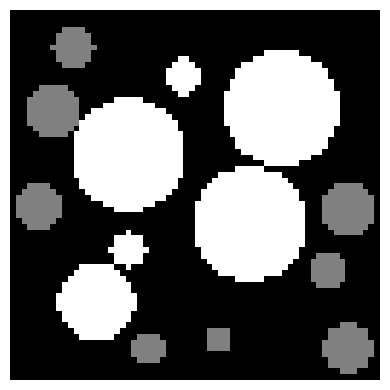

In [4]:
plt.figure(figsize=(4, 4))
plt.imshow(
    images[0, 0],
    cmap="gray",
    vmin=0,
    vmax=args.num_phases - 1,
    interpolation="nearest",
)
plt.axis("off")
plt.tight_layout()